# TextGrad Tutorial

![TextGrad](https://github.com/vinid/data/blob/master/logo_full.png?raw=true)

An autograd engine -- for textual gradients!

[![GitHub license](https://img.shields.io/badge/License-MIT-blue.svg)](https://lbesson.mit-license.org/)
[![Arxiv](https://img.shields.io/badge/arXiv-2406.07496-B31B1B.svg)](https://arxiv.org/abs/2406.07496)
[![PyPI](https://img.shields.io/pypi/v/textgrad)](https://pypi.org/project/textgrad/)

**Objectives**

* Understand the core method: variables, the five steps, and what each module looks like in code.
* Run the optimization loop on one question that the task model gets wrong at first, and see the prompt update fix it.
* Optimize a prompt on a dataset with train / validation / test sets.

**Setup.** Paste your OpenAI API key in the cell below and run it.

In [ ]:
%pip install -q textgrad

import os, random, logging
import textgrad as tg
logging.getLogger("textgrad").setLevel(logging.WARNING)   # hide per-call log lines

# Paste your OpenAI API key here (or set the OPENAI_API_KEY environment variable before starting the kernel).
OPENAI_API_KEY = ""

if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY in the line above."

# TextGrad: Core Method

TextGrad optimizes text variables by propagating natural-language feedback backward through a computation graph, then using an LLM to update the selected variables.

Its "gradients" are textual critiques, not numerical derivatives. The underlying LLM weights remain fixed.

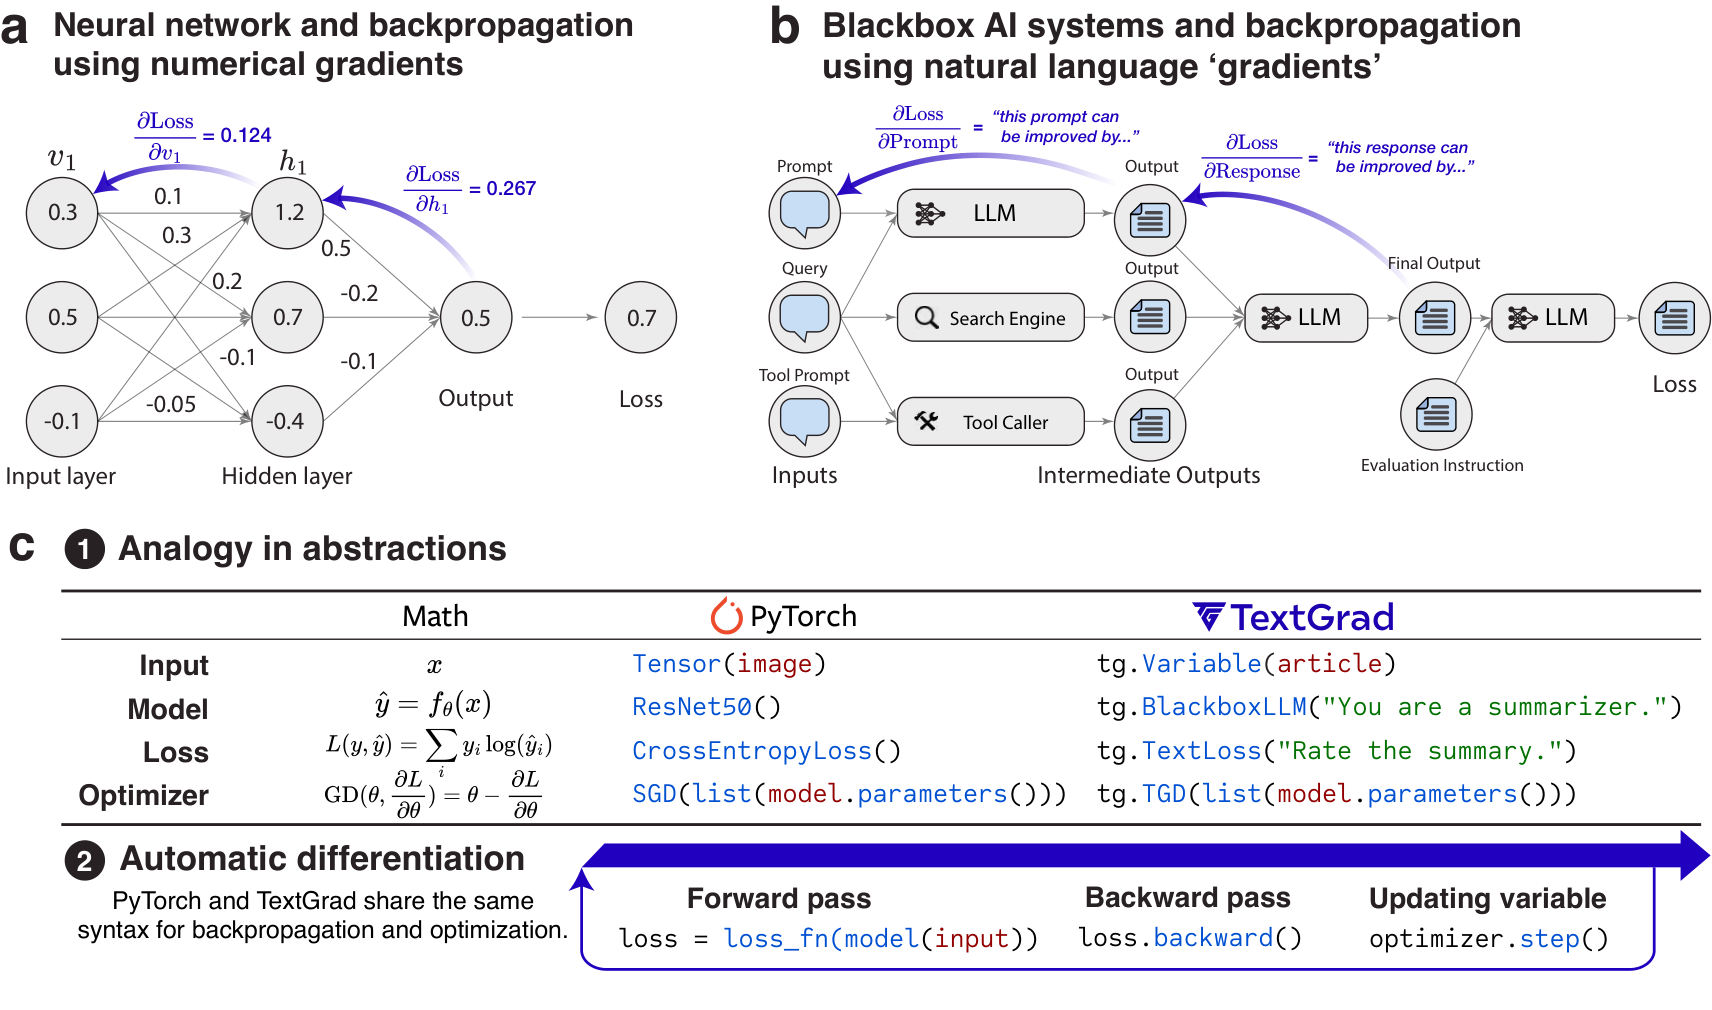

## 1. Core definitions

Running example (task model `gpt-3.5-turbo`, feedback model `gpt-4o`; every value below is from the real run recorded in this notebook):

> A number is increased by 50% and then decreased by 50%. Is the result larger than, smaller than, or equal to the original number?  (correct: smaller; the result is 0.75× the original)

| Symbol | Code | Meaning | In the example |
|---|---|---|---|
| $p$ | `prompt` | the reusable prompt being optimized (`requires_grad=True`) | `"Answer math questions concisely."` |
| $q$ | `question` | the fixed input question | `"A number is increased by 50% and then decreased by 50%. Is the result larger than, smaller than, or equal to the original number?"` |
| $y$ | `answer` | the answer generated with the current prompt | `"The result is equal to the original number."`  ✗ |
| $e$ | `evaluation` | the evaluator's assessment of the answer (the "loss", as text) | `"The proposed answer is incorrect. … 1.5x × 0.5 = 0.75x … the result is smaller than the original number."` |
| $g_y$ | `answer.get_gradient_text()` | feedback on the answer (a "gradient") | `"… is incorrect … provide a step-by-step breakdown … use specific numerical examples … verify the answer …"` |
| $g_p$ | `prompt.get_gradient_text()` | feedback on the prompt (a "gradient") | `"'Answer math questions concisely' prioritizes brevity over accuracy … instruct the model to provide a detailed explanation … verify the solution …"` |

Operators: $F$ the task model, $E$ the evaluator, $B_E$ / $B_F$ the backward passes through them, $U$ the optimizer's update.

## 2. Main steps

| Step | Formula | Code | In the example |
|---|---|---|---|
| 1. Generate an answer | $y = F(p,q)$ | `answer = model(question)` | `gpt-3.5-turbo` reads $p$ + $q$ → `"The result is equal to the original number."` ✗ |
| 2. Evaluate the answer | $e = E(q,y,a^\star)$ | `evaluation = loss_fn(answer)` | `gpt-4o` compares $y$ with the reference → `"incorrect … 0.75x … smaller"` |
| 3. Feedback on the answer | $g_y = B_E(y,e)$ | `evaluation.backward()` | `"show the steps, use a numerical example, verify"` |
| 4. Feedback on the prompt | $g_p = B_F(p,q,y,g_y)$ | (same call) | `"'concisely' trades accuracy for brevity; ask for a detailed, verified solution"` |
| 5. Update the prompt | $p_{\mathrm{new}} = U(p,g_p)$ | `optimizer.step()` | $p$ becomes `"Provide a detailed explanation and solution for each math question. Verify the solution against known mathematical principles, address common misconceptions, and use specific numerical examples …"` |
| (1 again) | $y = F(p_{\mathrm{new}},q)$ | `answer = model(question)` | `"… 0.75x … the result is smaller than the original number."` ✓ |

The central operation is step 4: *given this input, its resulting output, and the criticism of that output, how should the input change?* **`backward()` computes feedback; `step()` applies the update.**

The blocks below build the system one module at a time, then run the loop.

## 3. The modules, one at a time

### Engines

Two LLMs: a task engine for $F$, and a stronger feedback engine for $E$, $B_E$, $B_F$ and $U$. The task engine is deliberately weak (`gpt-3.5-turbo`): with the starting prompt it answers the running example wrong every time, so the loop has something to fix. `set_backward_engine` makes the feedback engine the default for `backward()`.

In [ ]:
import textgrad as tg

task_engine = tg.get_engine("gpt-3.5-turbo")     # F: a weak model, so there is something to fix
feedback_engine = tg.get_engine("gpt-4o")        # E, B_E, B_F, U
tg.set_backward_engine(feedback_engine, override=True)

### Variables: $p$ and $q$

Only the prompt has `requires_grad=True`; the question is fixed. The `role_description` is quoted in every feedback and update prompt, so it steers the optimization.

In [ ]:
prompt = tg.Variable(
    "Answer math questions concisely.",
    requires_grad=True,
    role_description="A reusable system prompt for solving different math questions.",
)

question = tg.Variable(
    "A number is increased by 50% and then decreased by 50%. "
    "Is the result larger than, smaller than, or equal to the original number?",
    requires_grad=False,
    role_description="A math question to answer.",
)

reference_answer = "smaller (the result is 75% of the original)"

### $F$: the task model — step 1, $y = F(p, q)$

`BlackboxLLM` is an LLM call parameterized by the prompt. Its output remembers `prompt` and `question` as predecessors: that is the computation graph.

In [ ]:
model = tg.BlackboxLLM(engine=task_engine, system_prompt=prompt)

answer = model(question)                              # y = F(p, q)
print(answer.value)
print("\npredecessors:", [v.get_role_description() for v in answer.predecessors])

The result is equal to the original number.

predecessors: ['A reusable system prompt for solving different math questions.', 'A math question to answer.']


### $E$: the evaluator — step 2, $e = E(q, y, a^\star)$

`TextLoss` is another LLM call whose system prompt is the evaluation instruction. The question and the reference answer are fixed inside that instruction. The output is text, not a number.

In [ ]:
evaluation_instruction = (
    "Evaluate the proposed answer for mathematical correctness.\n"
    f"Question: {question.value}\n"
    f"Reference answer: {reference_answer}\n"
    "Identify specific reasoning or calculation errors. "
    "If the answer is correct, explicitly say so."
)
loss_fn = tg.TextLoss(evaluation_instruction, engine=feedback_engine)

evaluation = loss_fn(answer)                          # e = E(q, y, a*)
print(evaluation.value)

The reference answer is correct, and the proposed answer is incorrect. Let's evaluate the situation step by step:

1. Start with an original number, say \( x \).

2. Increase the number by 50%:
   \[
   x + 0.5x = 1.5x
   \]

3. Decrease the result by 50%:
   \[
   1.5x - 0.5 \times 1.5x = 1.5x \times (1 - 0.5) = 1.5x \times 0.5 = 0.75x
   \]

The final result is \( 0.75x \), which is 75% of the original number \( x \). Therefore, the result is smaller than the original number. The reference answer is correct.


### $B_E$ and $B_F$: backward — steps 3 and 4

One call does both. First the feedback engine reads the evaluation and writes $g_y$, feedback on the answer. Then it reads the forward call (prompt + question → answer) together with $g_y$ and writes $g_p$, feedback on the prompt. Nothing is changed yet.

In [ ]:
evaluation.backward()                                 # g_y = B_E(y, e);  g_p = B_F(p, q, y, g_y)

print("Answer feedback g_y:\n", answer.get_gradient_text())
print("\nPrompt feedback g_p:\n", prompt.get_gradient_text())

Answer feedback g_y:
 The variable "The result is equal to the original number." is incorrect based on the mathematical evaluation provided. Here are some strategies to improve the response from the language model:

1. **Incorporate Step-by-Step Reasoning**: Encourage the language model to provide a step-by-step breakdown of the calculation process. This can help ensure that the model arrives at the correct conclusion. For example, it could start by defining the original number as \( x \), then show the increase and decrease calculations explicitly.

2. **Highlight Common Misconceptions**: The language model could be trained to recognize and address common misconceptions, such as the belief that increasing and then decreasing by the same percentage results in the original number. Including a brief explanation of why this is a misconception could improve understanding.

3. **Use Numerical Examples**: Suggest that the language model use specific numerical examples to illustrate the conce

### $U$: the optimizer — step 5, $p_{\mathrm{new}} = U(p, g_p)$

`TextualGradientDescent` holds the parameters to update. `step()` sends the current prompt, its role and its feedback to the feedback engine and replaces the prompt with the returned text. Constraints are plain sentences appended to that request.

In [ ]:
optimizer = tg.TextualGradientDescent(
    parameters=[prompt],
    engine=feedback_engine,
    constraints=[
        "Keep the prompt reusable across different math questions.",
        "Do not include this question's specific numbers or answer.",
    ],
)

optimizer.step()                                      # p_new = U(p, g_p)
print(prompt.value)

Provide a detailed explanation and solution for each math question. Verify the solution against known mathematical principles, address common misconceptions, and use specific numerical examples to illustrate your solution. Ensure clarity and understanding in your explanations, and cross-check your answer with alternative methods or reference answers.


## 4. The full loop

The same five steps, repeated. `zero_grad()` clears the previous feedback before each pass.

In [ ]:
for step in range(3):
    optimizer.zero_grad()

    answer = model(question)                          # 1. y = F(p, q)
    evaluation = loss_fn(answer)                      # 2. e = E(q, y, a*)
    evaluation.backward()                             # 3-4. g_y, then g_p
    optimizer.step()                                  # 5. p_new = U(p, g_p)

    print(f"\n=== Iteration {step + 1} ===")
    print("Answer:", answer.value)
    print("Evaluation:", evaluation.value)
    print("Prompt feedback:", prompt.get_gradient_text())
    print("Updated prompt:", prompt.value)

final_answer = model(question)
print("\nFinal answer:", final_answer.value)


=== Iteration 1 ===
Answer: Let's denote the original number as $x$. 

When the number is increased by 50%, it becomes $x + 0.5x = 1.5x$.

When this new number is decreased by 50%, it becomes $1.5x - 0.5(1.5x) = 1.5x - 0.75x = 0.75x$.

So, the final result after the two operations is 0.75 times the original number $x$.

Since $0.75x$ is less than $x$ for any positive value of $x$, the result after the two operations is smaller than the original number.
Evaluation: The reasoning and calculations provided are correct. 

1. The original number is denoted as \( x \).
2. Increasing the number by 50% results in \( 1.5x \).
3. Decreasing this new number by 50% results in \( 1.5x - 0.5(1.5x) = 1.5x - 0.75x = 0.75x \).

Thus, the final result is \( 0.75x \), which is indeed 75% of the original number \( x \). Since \( 0.75x \) is less than \( x \), the result is smaller than the original number. The reference answer is correct.
Prompt feedback: To improve the objective function, the reusable s

This example demonstrates the optimization mechanics on one question. Optimizing a reusable prompt in practice requires multiple training examples and separate validation; an update does not guarantee improvement. The next section does exactly that.

[Paper](https://arxiv.org/abs/2406.07496) · [Official implementation](https://github.com/zou-group/textgrad)

---

# Prompt Optimization on a Dataset

Same five steps, three additions that make the prompt generalize:

* **Batch:** several questions per step; their evaluations are combined with `tg.sum`, so the prompt receives one piece of feedback per question.
* **Validation gate:** after every `step()`, evaluate on a validation set and revert the prompt if accuracy dropped.
* **Test set:** evaluated after every step, only to report progress.

Task: BIG-Bench Hard *Object Counting*, 50 / 100 / 100 train / val / test. The task model is `gpt-3.5-turbo`; `gpt-4o` provides feedback and updates. The loss is exact match on the final number (`StringBasedFunction`), so the signal is grounded rather than an LLM's opinion. This is section 3 of the official tutorial; the outputs are from a real run.

In [26]:
# Dataset loading and parallel evaluation.
import concurrent.futures
import numpy as np
from tqdm import tqdm
from textgrad.tasks import load_task

Let's first define some support functions

In [27]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)

In [33]:
def eval_sample(item, eval_fn, model):
    """
    This function allows us to evaluate if an answer to a question in the prompt is a good answer.

    """
    x, y = item
    x = tg.Variable(x, requires_grad=False, role_description="query to the language model")
    y = tg.Variable(str(y), requires_grad=False, role_description="correct answer for the query")
    response = model(x)
    try:
        eval_output_variable = eval_fn(inputs=dict(prediction=response, ground_truth_answer=y))
        return int(eval_output_variable.value)
    except:
        eval_output_variable = eval_fn([x, y, response])
        eval_output_parsed = eval_fn.parse_output(eval_output_variable)
        return int(eval_output_parsed)

In [29]:
def eval_dataset(test_set, eval_fn, model, max_samples: int=None):
    if max_samples is None:
        max_samples = len(test_set)
    accuracy_list = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        futures = []
        for _, sample in enumerate(test_set):

            future = executor.submit(eval_sample, sample, eval_fn, model)
            futures.append(future)
            if len(futures) >= max_samples:
                break
        tqdm_loader = tqdm(concurrent.futures.as_completed(futures), total=len(futures), position=0)
        for future in tqdm_loader:
            acc_item = future.result()
            accuracy_list.append(acc_item)
            tqdm_loader.set_description(f"Accuracy: {np.mean(accuracy_list)}")
    return accuracy_list

In [30]:
def run_validation_revert(system_prompt: tg.Variable, results, model, eval_fn, val_set):
    val_performance = np.mean(eval_dataset(val_set, eval_fn, model))
    previous_performance = np.mean(results["validation_acc"][-1])
    print("val_performance: ", val_performance)
    print("previous_performance: ", previous_performance)
    previous_prompt = results["prompt"][-1]

    if val_performance < previous_performance:
        print(f"rejected prompt: {system_prompt.value}")
        system_prompt.set_value(previous_prompt)
        val_performance = previous_performance

    results["validation_acc"].append(val_performance)

In [31]:
set_seed(12)
llm_api_eval = tg.get_engine(engine_name="gpt-4o")
llm_api_test = tg.get_engine(engine_name="gpt-3.5-turbo-0125")
tg.set_backward_engine(llm_api_eval, override=True)

# Load the data and the evaluation function
train_set, val_set, test_set, eval_fn = load_task("BBH_object_counting", evaluation_api=llm_api_eval)
print("Train/Val/Test Set Lengths: ", len(train_set), len(val_set), len(test_set))
STARTING_SYSTEM_PROMPT = train_set.get_task_description()


Train/Val/Test Set Lengths:  50 100 100


This is the system prompt we are going to start from:

In [34]:
print(STARTING_SYSTEM_PROMPT)


You will answer a reasoning question. Think step by step. The last line of your response should be of the following format: 'Answer: $VALUE' where VALUE is a numerical value.


In [35]:
train_loader = tg.tasks.DataLoader(train_set, batch_size=3, shuffle=True)


# Testing the 0-shot performance of the evaluation engine
system_prompt = tg.Variable(STARTING_SYSTEM_PROMPT,
                            requires_grad=True,
                            role_description="system prompt to the language model")
model_evaluation = tg.BlackboxLLM(llm_api_eval, system_prompt)

system_prompt = tg.Variable(STARTING_SYSTEM_PROMPT,
                            requires_grad=True,
                            role_description="structured system prompt to a somewhat capable language model that specifies the behavior and strategies for the QA task")
model = tg.BlackboxLLM(llm_api_test, system_prompt)

optimizer = tg.TextualGradientDescent(engine=llm_api_eval, parameters=[system_prompt])

results = {"test_acc": [], "prompt": [], "validation_acc": []}
results["test_acc"].append(eval_dataset(test_set, eval_fn, model))
results["validation_acc"].append(eval_dataset(val_set, eval_fn, model))
results["prompt"].append(system_prompt.get_value())


  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.0:   1%|          | 1/100 [00:01<02:21,  1.43s/it]Accuracy: 0.5:   2%|▏         | 2/100 [00:02<01:45,  1.08s/it]Accuracy: 0.3333333333333333:   3%|▎         | 3/100 [00:02<01:13,  1.32it/s]Accuracy: 0.5:   4%|▍         | 4/100 [00:03<01:04,  1.49it/s]Accuracy: 0.4:   5%|▌         | 5/100 [00:04<01:11,  1.33it/s]Accuracy: 0.3333333333333333:   6%|▌         | 6/100 [00:04<00:52,  1.79it/s]Accuracy: 0.42857142857142855:   7%|▋         | 7/100 [00:04<00:53,  1.75it/s]Accuracy: 0.5:   8%|▊         | 8/100 [00:05<00:57,  1.61it/s]Accuracy: 0.5555555555555556:   9%|▉         | 9/100 [00:06<01:02,  1.46it/s]Accuracy: 0.6:  10%|█         | 10/100 [00:06<00:55,  1.61it/s]Accuracy: 0.6363636363636364:  11%|█         | 11/100 [00:07<01:03,  1.40it/s]Accuracy: 0.5833333333333334:  12%|█▏        | 12/100 [00:08<00:56,  1.55it/s]Accuracy: 0.5384615384615384:  13%|█▎        | 13/100 [00:08<00:45,  1.92it/s]Accuracy: 0.5:  14%|█▍        | 14/100 [00:08

In [ ]:
for epoch in range(3):
    for steps, (batch_x, batch_y) in enumerate((pbar := tqdm(train_loader, position=0))):
        pbar.set_description(f"Training step {steps}. Epoch {epoch}")
        optimizer.zero_grad()
        losses = []
        for (x, y) in zip(batch_x, batch_y):
            x = tg.Variable(x, requires_grad=False, role_description="query to the language model")
            y = tg.Variable(str(y), requires_grad=False, role_description="correct answer for the query")
            response = model(x)
            try:
                eval_output_variable = eval_fn(inputs=dict(prediction=response, ground_truth_answer=y))
            except:
                eval_output_variable = eval_fn([x, y, response])
            losses.append(eval_output_variable)
        total_loss = tg.sum(losses)
        total_loss.backward()
        optimizer.step()

        run_validation_revert(system_prompt, results, model, eval_fn, val_set)

        print("sys prompt: ", system_prompt)
        test_acc = eval_dataset(test_set, eval_fn, model)
        results["test_acc"].append(test_acc)
        results["prompt"].append(system_prompt.get_value())
        if steps == 3:
            break

Training step 0. Epoch 0: : 0it [00:00, ?it/s]  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   1%|          | 1/100 [00:01<01:40,  1.01s/it]Accuracy: 1.0:   2%|▏         | 2/100 [00:01<00:59,  1.64it/s]Accuracy: 1.0:   3%|▎         | 3/100 [00:01<00:57,  1.69it/s]Accuracy: 1.0:   4%|▍         | 4/100 [00:02<01:15,  1.28it/s]Accuracy: 1.0:   5%|▌         | 5/100 [00:03<01:04,  1.46it/s]Accuracy: 0.8333333333333334:   6%|▌         | 6/100 [00:04<01:01,  1.53it/s]Accuracy: 0.8571428571428571:   7%|▋         | 7/100 [00:05<01:17,  1.20it/s]Accuracy: 0.875:   8%|▊         | 8/100 [00:05<01:01,  1.50it/s]Accuracy: 0.8888888888888888:   9%|▉         | 9/100 [00:06<01:07,  1.35it/s]Accuracy: 0.9:  10%|█         | 10/100 [00:07<01:07,  1.34it/s]Accuracy: 0.8181818181818182:  10%|█         | 10/100 [00:07<01:07,  1.34it/s]Accuracy: 0.8333333333333334:  12%|█▏        | 12/100 [00:07<00:47,  1.85it/s]Accuracy: 0.8461538461538461:  13%|█▎        | 13/100 [00:08<00:38,  2.29it/s]Accuracy: 0.8

val_performance:  0.93
previous_performance:  0.68
sys prompt:  You will answer a reasoning question. Provide a concise and direct response, focusing only on necessary information. List each item and its quantity using bullet points, then add them together, explaining each step clearly. Use mathematical symbols for calculations to enhance clarity and processing efficiency. Avoid redundant statements; focus on listing and the final answer. Place the final answer on a new line, prefixed by 'Total:' for clarity. Ensure the list only includes relevant items and clarify any potential ambiguities. Prioritize efficiency in your response to facilitate quick parsing. The last line of your response should be of the following format: 'Total: $VALUE' where VALUE is a numerical value.


  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   1%|          | 1/100 [00:00<01:26,  1.15it/s]Accuracy: 1.0:   2%|▏         | 2/100 [00:01<00:58,  1.68it/s]Accuracy: 1.0:   3%|▎         | 3/100 [00:02<01:18,  1.23it/s]Accuracy: 1.0:   4%|▍         | 4/100 [00:02<01:01,  1.57it/s]Accuracy: 1.0:   5%|▌         | 5/100 [00:03<00:59,  1.59it/s]Accuracy: 1.0:   6%|▌         | 6/100 [00:03<00:51,  1.84it/s]Accuracy: 0.8571428571428571:   7%|▋         | 7/100 [00:04<00:49,  1.90it/s]Accuracy: 0.75:   7%|▋         | 7/100 [00:04<00:49,  1.90it/s]              Accuracy: 0.7777777777777778:   9%|▉         | 9/100 [00:05<00:44,  2.03it/s]Accuracy: 0.8:  10%|█         | 10/100 [00:05<00:40,  2.22it/s]Accuracy: 0.8181818181818182:  11%|█         | 11/100 [00:05<00:40,  2.22it/s]Accuracy: 0.8333333333333334:  12%|█▏        | 12/100 [00:06<00:33,  2.62it/s]Accuracy: 0.8461538461538461:  13%|█▎        | 13/100 [00:06<00:32,  2.71it/s]Accuracy: 0.8571428571428571:  14%|█▍        | 14/100 [00:07<

val_performance:  0.61
previous_performance:  0.93
rejected prompt: You will answer a reasoning question. Provide a concise and direct response, focusing solely on calculating and stating the total number of items. Avoid listing each item individually. Ensure your response is unambiguous and directly answers the question without extraneous information. Perform a quick internal verification of the total before outputting the response to minimize errors. The final answer should be on a single line, prefixed by 'Total:' for clarity and consistency. The format should be 'Total: $VALUE' where VALUE is a numerical value.
sys prompt:  You will answer a reasoning question. Provide a concise and direct response, focusing only on necessary information. List each item and its quantity using bullet points, then add them together, explaining each step clearly. Use mathematical symbols for calculations to enhance clarity and processing efficiency. Avoid redundant statements; focus on listing and the

Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.75:   0%|          | 0/100 [00:00<?, ?it/s]              Accuracy: 0.7777777777777778:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8:   0%|          | 0/100 [00:00<?, ?it/s]               Accuracy: 0.8181818181818182:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8333333333333334:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8461538461538461:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8666666666666667:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.875:   0%|          | 0/100 [00:00<?, ?it/s

...

  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.75:   0%|          | 0/100 [00:00<?, ?it/s]              Accuracy: 0.7777777777777778:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8:   0%|          | 0/100 [00:00<?, ?it/s]               Accuracy: 0.8181818181818182:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8333333333333334:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8461538461538461:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.875:   0%|          | 0/100 [00:00<?, ?it/s]             Accuracy: 0.8823529411764706:   0%|          | 0/100 [00:00<?, ?it/s]A

val_performance:  0.94
previous_performance:  0.93
sys prompt:  You will answer a reasoning question. Provide a concise and direct response, focusing only on necessary information. Use singular forms for all item names to maintain consistency and clarity. List each item and its quantity using bullet points with indentation for better readability, ensuring each item follows the format 'Item: Quantity' without deviation. Use dashes for bullet points consistently. Avoid using ellipses or any ambiguous symbols; each item must have a clear and specific count. After listing all items, verify the sum of quantities matches the total provided. If discrepancies are found, correct them before finalizing the response. Include an explicit summation step in your response to demonstrate the calculation process, e.g., 'Sum of individual counts: 1 + 1 + 1 = 3'. Place the final answer on a new line, prefixed by 'Total:' for clarity, and ensure it is presented as a plain numerical value without any symbo

  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   1%|          | 1/100 [00:00<01:23,  1.18it/s]Accuracy: 1.0:   2%|▏         | 2/100 [00:01<00:49,  1.96it/s]Accuracy: 1.0:   3%|▎         | 3/100 [00:01<00:37,  2.61it/s]Accuracy: 1.0:   4%|▍         | 4/100 [00:02<00:48,  1.96it/s]Accuracy: 1.0:   5%|▌         | 5/100 [00:02<00:57,  1.66it/s]Accuracy: 1.0:   6%|▌         | 6/100 [00:03<00:49,  1.90it/s]Accuracy: 0.8571428571428571:   7%|▋         | 7/100 [00:04<01:04,  1.45it/s]Accuracy: 0.75:   8%|▊         | 8/100 [00:04<00:49,  1.87it/s]Accuracy: 0.7777777777777778:   9%|▉         | 9/100 [00:05<01:04,  1.41it/s]Accuracy: 0.8:   9%|▉         | 9/100 [00:05<01:04,  1.41it/s]               Accuracy: 0.8181818181818182:  11%|█         | 11/100 [00:06<00:56,  1.58it/s]Accuracy: 0.8333333333333334:  12%|█▏        | 12/100 [00:06<00:44,  1.97it/s]Accuracy: 0.8461538461538461:  13%|█▎        | 13/100 [00:07<00:50,  1.71it/s]Accuracy: 0.8571428571428571:  14%|█▍        | 14/100 [00:08<

val_performance:  0.92
previous_performance:  0.94
rejected prompt: You will answer a reasoning question. Provide a concise and direct response, focusing only on necessary information. Use singular forms for all item names to maintain consistency and clarity. List each item and its quantity using bullet points with indentation for better readability, ensuring each item follows the format 'Item: Quantity' without deviation. Use dashes for bullet points consistently. Avoid using ellipses or any ambiguous symbols; each item must have a clear and specific count. 

Explicitly list every item mentioned in the input, ensuring no omissions. After listing all items, verify the sum of quantities matches the total provided. If discrepancies are found, correct them before finalizing the response. Include an explicit summation step in your response to demonstrate the calculation process, e.g., 'Sum of individual counts: 1 + 1 + 1 = 3'. Place the final answer on a new line, prefixed by 'Total:' for 

  0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 1.0:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.75:   0%|          | 0/100 [00:00<?, ?it/s]              Accuracy: 0.7777777777777778:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8:   0%|          | 0/100 [00:00<?, ?it/s]               Accuracy: 0.8181818181818182:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8333333333333334:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8461538461538461:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8571428571428571:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.8666666666666667:   0%|          | 0/100 [00:00<?, ?it/s]Accuracy: 0.875: